In [41]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")


'true'

In [42]:
# Set up folders from root 
CWD = Path.cwd()
PARENT = CWD.parent / "backend"
PARENT

for p in (CWD, PARENT, PARENT / "syntheticData"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))


In [43]:
import scripts as SCRIPTS

# Connect to Postgres on Heroku
# req: .env DATABASE_URL and SECRET_KEY
try:
    study_report = SCRIPTS.build_study_report()
    for k, v in study_report["feasibility"].items():
            print(f"  {k:36s} {v}")

except Exception as e:
      print(e)

  ema_response_rate_pct                100.0
  wear_time_mean_hrs_per_day           nan
  wear_time_days_meeting_goal          0
  retention_pct                        nan
  intervention_dosage_mean_per_day     nan
  cooldown_violation_count             16
  daily_cap_violation_count            1
  delivery_funnel_received_pct         86.95652173913044
  run_in_mssd_mean                     nan
  overall_lt_mssd_mean                 0.1503124999999998
  enrolled_without_enrolled_at         1


In [44]:
# LOAD SOURCE TABLES

ema_df   = SCRIPTS.load_ema()
item_df  = SCRIPTS.load_ema_item_responses()
jitai_df = SCRIPTS.load_jitai_log()
hr_df    = SCRIPTS.load_heart_rate()
eng_df   = SCRIPTS.load_engagement_log()
user_df  = SCRIPTS.load_users()

print("rows:", dict(ema=len(ema_df), items=len(item_df), jitai=len(jitai_df),
                    hr=len(hr_df), engagement=len(eng_df), users=len(user_df)))
ema_df.head()

rows: {'ema': 15, 'items': 419, 'jitai': 27, 'hr': 0, 'engagement': 116, 'users': 6}


,id,user_id,prompt_id,sent_at,responded_at,status,ema_type,source_jitai_log_id,outcome_window_start,outcome_window_end,expires_at,mood,stress,energy
0,8553,529,EMA-529-20260909190707,2026-09-09 19:09:25.247047+00:00,2026-09-09 19:09:25.246875+00:00,completed,scheduled_check_in,NaN,NaT,NaT,NaT,None,None,None
1,8552,463,EMA-463-20260909171117,2026-09-09 17:11:45.655270+00:00,2026-09-09 17:11:45.655066+00:00,completed,scheduled_check_in,202.0,NaT,NaT,NaT,None,None,None
2,8551,463,EMA-463-20260909171050,2026-09-09 17:11:12.755674+00:00,2026-09-09 17:11:12.755247+00:00,completed,scheduled_check_in,NaN,NaT,NaT,NaT,None,None,None
3,8550,463,EMA-463-20260909171015,2026-09-09 17:10:44.222220+00:00,2026-09-09 17:10:44.221993+00:00,completed,scheduled_check_in,NaN,NaT,NaT,NaT,None,None,None
4,8549,463,EMA-463-20260909170829,2026-09-09 17:09:44.570259+00:00,2026-09-09 17:09:44.569966+00:00,completed,scheduled_check_in,NaN,NaT,NaT,NaT,None,None,None


EMA response rate (per participant + ALL):


,user_id,delivered,completed,response_rate_pct
0,430,4,4,100.0
1,463,6,6,100.0
2,464,4,4,100.0
3,529,1,1,100.0
4,ALL,15,15,100.0


median response latency (min): -0.0

Item missingness (cohort ALL rows):


,user_id,item,missing_count,delivered_count,missing_pct
12,ALL,mood,15,15,100.0
13,ALL,stress,15,15,100.0
14,ALL,energy,15,15,100.0


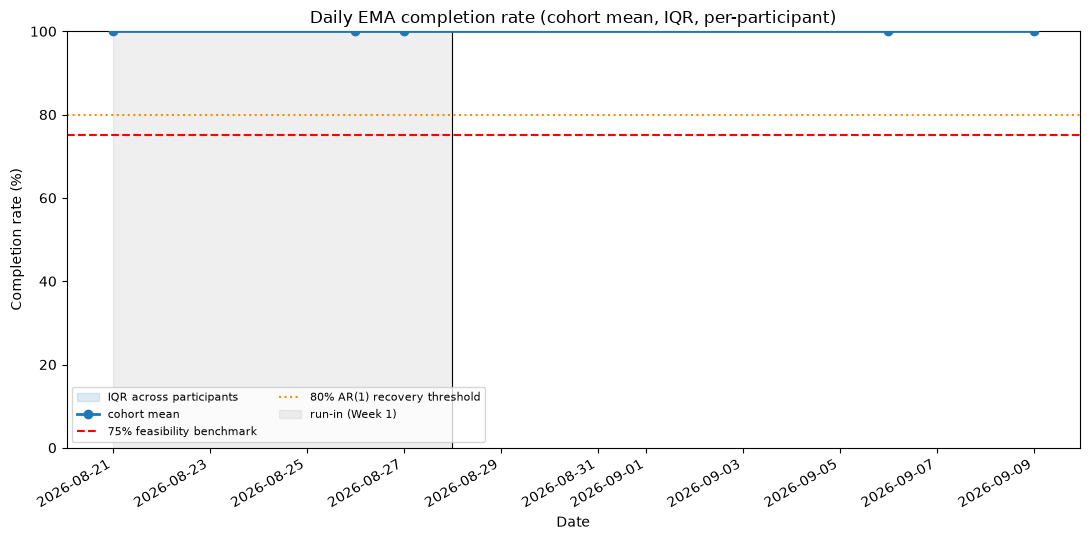

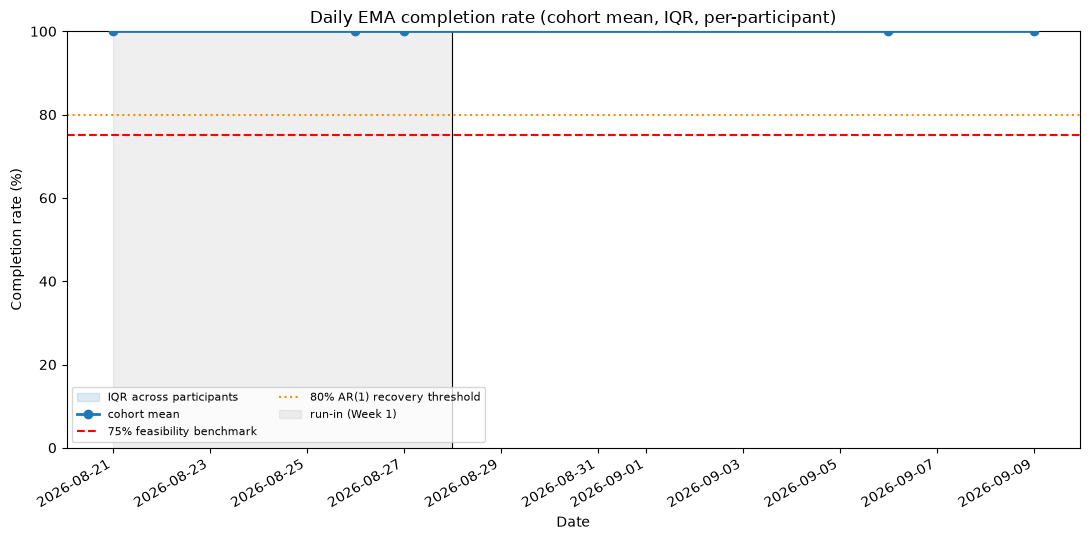

In [45]:
resp = SCRIPTS.compute_ema_response_rate(ema_df)
print("EMA response rate (per participant + ALL):")
display(resp)

lat = SCRIPTS.compute_response_latency(ema_df)
print("median response latency (min):", round(float(lat.median()), 1))

print("\nItem missingness (cohort ALL rows):")
display(SCRIPTS.compute_item_missingness(ema_df).query("user_id == 'ALL'"))

# EMA COMPLETION RATE
fig = SCRIPTS.plot_ema_completion_over_time(ema_df, user_df)
fig


In [46]:
from decision_engine.decision_engine import calculate_mssd
from dashboard.data.config import MSSD_WINDOW
from app.tasks import SIGNAL_SUB_ITEMS

signal = SCRIPTS._prep_trigger_signal(item_df, user_df)

print("Rows: ", len(signal))
assert SCRIPTS.compute_mssd(pd.Series([4,5,3,np.nan,6])) == 2.5

# Versions
base = (signal.sort_values("sent_at")
        .groupby("user_id")["value_numeric"].apply(SCRIPTS.compute_mssd)
        .rename("base_mssd").reset_index())
run_in = SCRIPTS.compute_run_in_mssd(signal)     # week-1 baseline
lt     = SCRIPTS.compute_lt_mssd(signal)         # long-term, on daily means

# Production version
wanted   = set(SIGNAL_SUB_ITEMS.values())
sub      = item_df[item_df["sub_item_id"].isin(wanted)]
complete = sub.groupby(["user_id", "ema_id", "sent_at"])["sub_item_id"].nunique()
keep     = complete[complete == len(wanted)].reset_index()[["user_id", "ema_id", "sent_at"]]
engine_signal = (sub.merge(keep, on=["user_id", "ema_id", "sent_at"])
                 .groupby(["user_id", "ema_id", "sent_at"], as_index=False)["value_numeric"].mean()
                 .rename(columns={"sent_at": "timestamp", "value_numeric": "ema"}))

engine = calculate_mssd(engine_signal[["user_id", "timestamp", "ema"]], window=MSSD_WINDOW)
engine_summary = (engine.groupby("user_id")["observed_mssd"]
                  .agg(engine_mssd_last="last", engine_mssd_mean="mean").reset_index())

# What production actually recorded 
logged = (jitai_df.dropna(subset=["observed_mssd"]).sort_values("decision_made_at")
          .groupby("user_id")["observed_mssd"]
          .agg(logged_mssd_last="last", logged_mssd_mean="mean").reset_index())


mssd_table = (run_in.merge(lt, on="user_id", how="outer")
              .merge(base, on="user_id", how="outer")
              .merge(engine_summary, on="user_id", how="outer")
              .merge(logged, on="user_id", how="outer")
              .sort_values("user_id"))

display(signal)
display(mssd_table)


Rows:  15


,user_id,ema_id,sent_at,value_numeric,enrolled_at
0,430,8494,2026-08-21 04:57:38.306988+00:00,5.8,NaT
1,430,8521,2026-08-27 21:03:15.495740+00:00,5.8,NaT
2,430,8522,2026-08-27 23:16:52.774014+00:00,5.0,NaT
3,430,8548,2026-09-06 22:24:19.525166+00:00,5.8,NaT
4,463,8515,2026-08-26 18:33:38.392311+00:00,3.0,NaT
5,463,8516,2026-08-26 18:35:13.065790+00:00,2.3,NaT
6,463,8549,2026-09-09 17:09:44.570259+00:00,2.3,NaT
7,463,8550,2026-09-09 17:10:44.222220+00:00,3.1,NaT
8,463,8551,2026-09-09 17:11:12.755674+00:00,3.0,NaT
9,463,8552,2026-09-09 17:11:45.655270+00:00,3.7,NaT


,user_id,run_in_mssd,lt_mssd,base_mssd,engine_mssd_last,engine_mssd_mean,logged_mssd_last,logged_mssd_mean
0,430,NaN,0.160000,0.426667,0.666667,0.388889,0.666667,0.388889
1,463,NaN,0.140625,0.326000,1.259259,1.807407,NaN,NaN
2,464,NaN,NaN,0.083333,0.333333,0.611111,NaN,NaN
3,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN


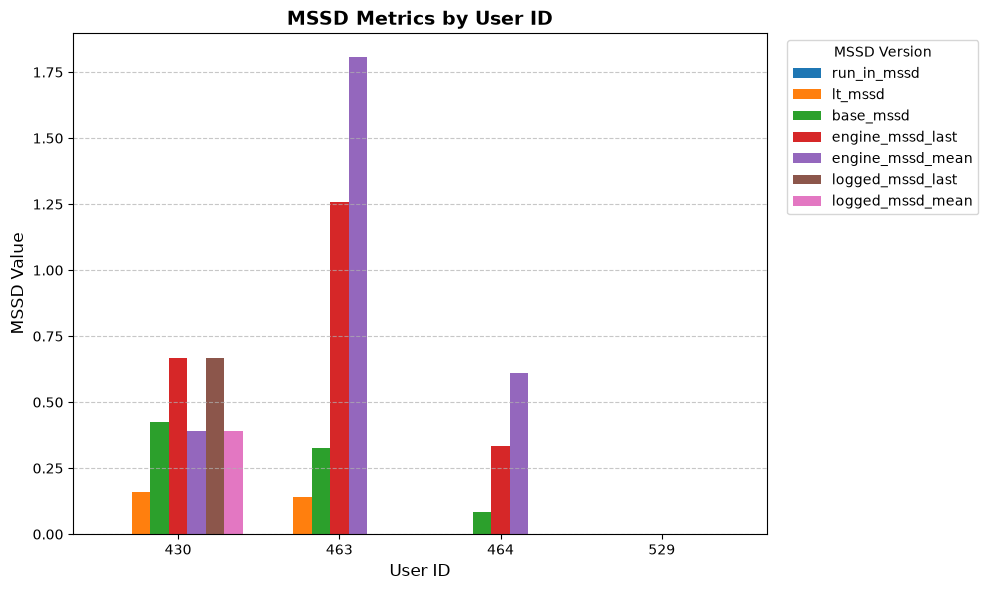

In [47]:
mssd_table['user_id'] = mssd_table['user_id'].astype(str)

# 2. Plot grouped bars
ax = mssd_table.set_index('user_id').plot(kind='bar', figsize=(10, 6), width=0.8)

# 3. Format visual elements
plt.title('MSSD Metrics by User ID', fontsize=14, weight='bold')
plt.xlabel('User ID', fontsize=12)
plt.ylabel('MSSD Value', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='MSSD Version', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [48]:
# AR(1) recovery per participant
# estimated (rho, sigma)
ar_rows = []
for uid, g in signal.sort_values("sent_at").groupby("user_id"):
    rho, sig = SCRIPTS.compute_ar1_parameters(g["value_numeric"])

    ar_rows.append(dict(user_id       = uid, 
                        rho_hat       = round(rho,3), 
                        sigma_hat     = round(sig,3),
                        expected_mssd = round(SCRIPTS.compute_expected_mssd(sig, rho),3)))
display(pd.DataFrame(ar_rows))


# get 80th percentile threshold
thr = SCRIPTS.compute_within_person_threshold(signal, quantile=0.80)
print("THRESHOLD: ", thr)
print("within-person threshold: non-null values =", int(thr.notna().sum()), "of", len(thr))

,user_id,rho_hat,sigma_hat,expected_mssd
0,430,-0.455,0.400,0.465
1,463,0.359,0.533,0.364
2,464,-0.091,0.250,0.136
3,529,NaN,NaN,NaN


THRESHOLD:  0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8     0.444667
9     0.422000
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
Name: value_numeric, dtype: float64
within-person threshold: non-null values = 2 of 15


In [49]:
# Step 6 — Wearable / wear-time (benchmark config.BENCHMARKS['wear'], currently 80% of the 14 h waking window)
wear = SCRIPTS.compute_wear_time(hr_df)
print("wear-time rows (user-day):", len(wear))
print("mean wear h/day:", round(float((wear['wear_minutes']/60).mean()), 2))
display(wear.head())
print("wear gaps (>2h) detected:", len(SCRIPTS.identify_wear_gaps(hr_df)))

wear-time rows (user-day): 0
mean wear h/day: nan


,user_id,date,wear_minutes,wear_pct


wear gaps (>2h) detected: 0


In [50]:
# Step 7 — JITAI decision audit (two-stage: eligibility -> randomization)
# Kept strictly separate per PI sign-off (p = 0.50, cooldown 60 min, cap 4/day).
print("Decision-stage audit (per participant + ALL):")
display(SCRIPTS.audit_decision_stages(jitai_df))

cd = SCRIPTS.check_cooldown_compliance(jitai_df)
cap = SCRIPTS.check_daily_cap_compliance(jitai_df)
print("cooldown violations:", int(cd['violation'].sum()) if len(cd) else 0,
      "| daily-cap violations:", int(cap['exceeds_cap'].sum()) if len(cap) else 0)

dose = SCRIPTS.compute_intervention_dosage(
    jitai_df.drop(columns=['enrolled_at'], errors='ignore')
            .merge(user_df[['user_id','enrolled_at']], on='user_id', how='left'))
print("mean dosage on active days:",
      round(float(dose.loc[dose['is_active_phase'],'prompts_sent'].mean()), 2) if len(dose) else float('nan'))

Decision-stage audit (per participant + ALL):


,user_id,total_decision_points,eligible,randomized_to_send,sent,not_sent,pct_sent_of_eligible
0,430,9,0,0,5,4,NaN
1,463,5,0,0,5,0,NaN
2,464,11,0,0,11,0,NaN
3,529,2,0,0,2,0,NaN
4,ALL,27,0,0,23,4,NaN


cooldown violations: 16 | daily-cap violations: 1
mean dosage on active days: nan


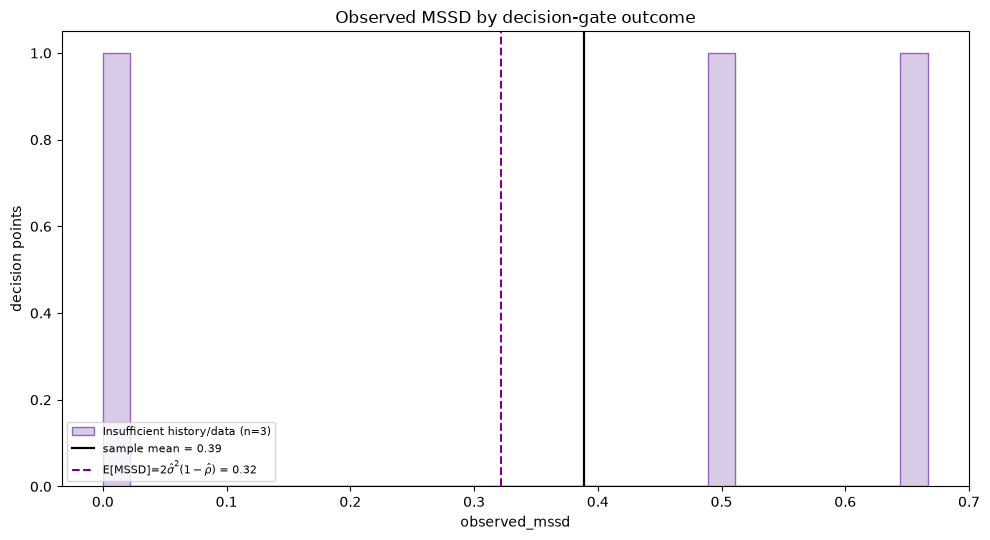

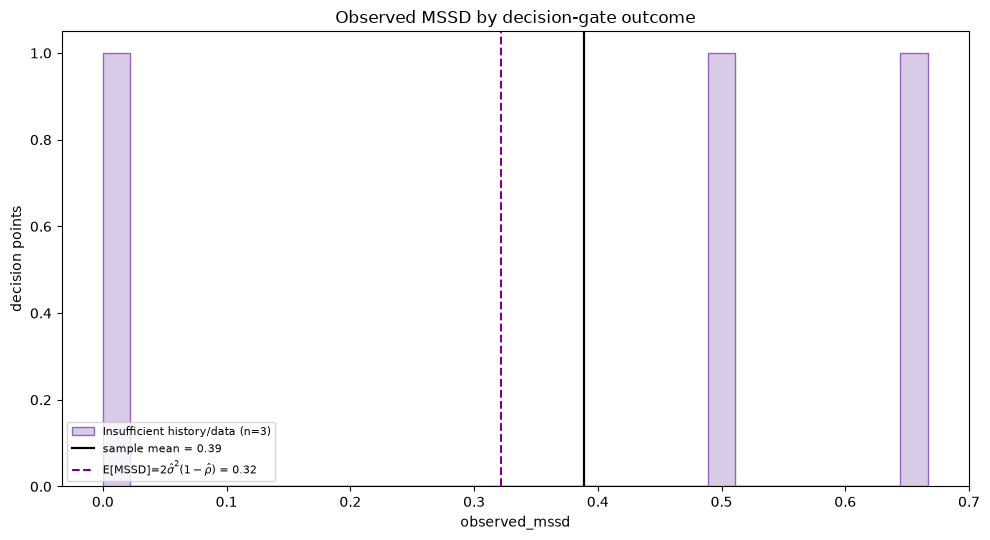

In [51]:
fig = SCRIPTS.plot_mssd_distribution(jitai_df, item_df=item_df)
fig

,stage,count,pct_of_sent
0,sent,23,100.000000
1,accepted_by_expo,4,17.391304
2,received_on_device,20,86.956522
3,receipt_reported,20,86.956522


median end-to-end pipeline (s): 14.08


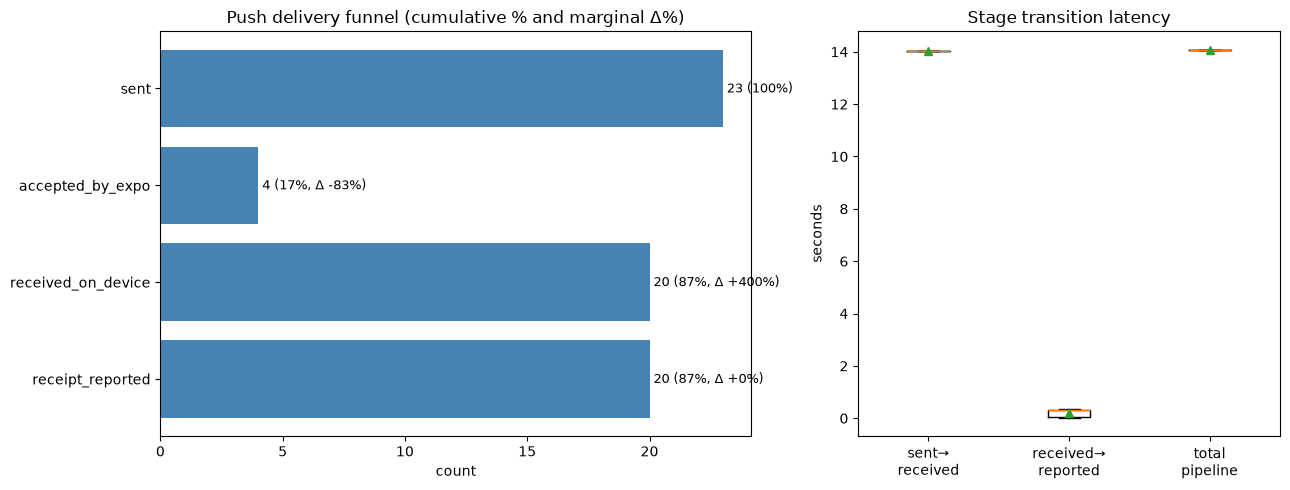

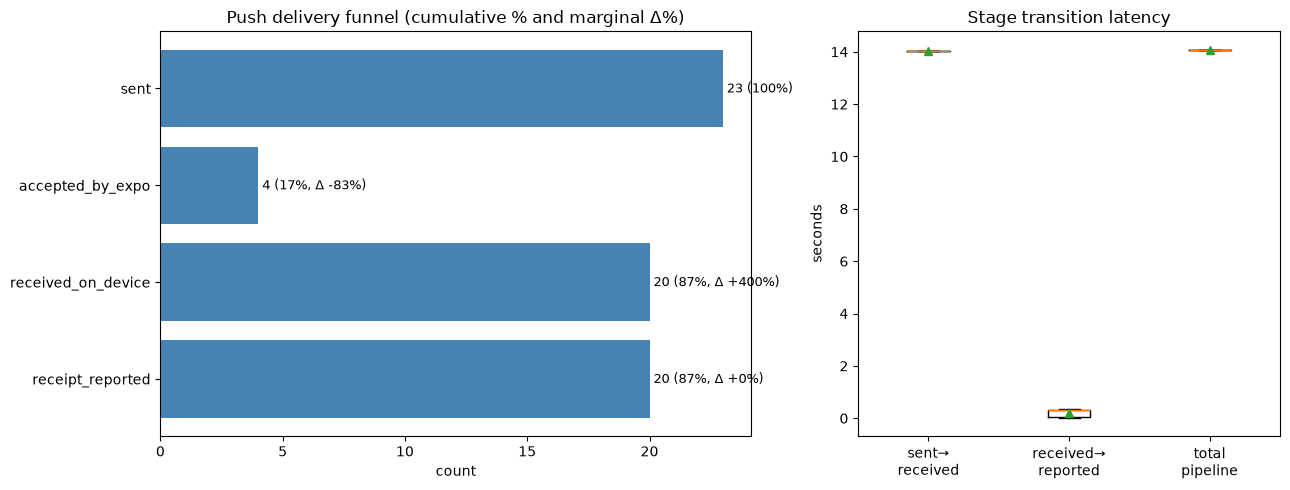

In [52]:
# Step 8 — Push delivery funnel + latency
display(SCRIPTS.compute_delivery_funnel(jitai_df))
pl = SCRIPTS.compute_push_latency(jitai_df)
print("median end-to-end pipeline (s):", round(float(pl['total_pipeline_sec'].median()), 2))
fig = SCRIPTS.plot_delivery_funnel(jitai_df)
fig

In [53]:
# Step 9 — Engagement
display(SCRIPTS.compute_engagement_rates(eng_df, jitai_df))
ol = SCRIPTS.compute_open_latency(eng_df, jitai_df)
print("median open latency (min):", round(float(ol.median()), 1) if len(ol) else float('nan'))

,user_id,delivered,opened,acted,dismissed,open_rate_pct,act_rate_pct,dismiss_rate_pct
0,430,2,3,0,2,150.000000,0.0,100.000000
1,463,5,5,1,2,100.000000,20.0,40.000000
2,464,11,4,0,4,36.363636,0.0,36.363636
3,529,2,1,0,1,50.000000,0.0,50.000000
4,ALL,20,13,1,9,65.000000,5.0,45.000000


median open latency (min): 2.1


In [54]:
# Step 10 — Retention & dropout
ret = SCRIPTS.compute_retention(user_df)
print("retention:", {k: (round(v,1) if isinstance(v,float) else v) for k,v in ret.items()})
print("\nDropout classification:")
display(SCRIPTS.classify_dropout(user_df, ema_df))

retention: {'overall_n': 0, 'retained_n': 0, 'overall_retention_pct': nan, 'run_in_retained_n': 0, 'run_in_retention_pct': nan, 'active_retained_n': 0, 'active_retention_pct': nan, 'undated_enrolled_n': 1}

Dropout classification:


,user_id,classification,last_active_date,days_since_active
0,430,active,2026-09-06,4.0
1,464,formal_withdrawal,2026-08-27,14.0
2,463,formal_withdrawal,2026-09-09,1.0
3,529,formal_withdrawal,2026-09-09,1.0
4,496,formal_withdrawal,NaT,NaN
5,497,formal_withdrawal,NaT,NaN


In [55]:
# Step 11 — HR <-> EMA volatility concordance
conc = SCRIPTS.compute_hr_ema_concordance(hr_df, signal)
display(conc)

,user_id,pearson_r,p_value,n_paired_observations


In [56]:
# Step 12 — Overall study report
# build_study_report() bundles every cohort-level table. Built outright rather
# than reused from cell 2, whose try/except can leave the name unbound.
study_report = SCRIPTS.build_study_report()

print("Feasibility scorecard (cohort):")
scorecard = pd.DataFrame([study_report['feasibility']]).T.rename(columns={0: 'value'})
display(scorecard)

print("\nPer-participant LT-MSSD:")
display(study_report['lt_mssd_per_user'])

Feasibility scorecard (cohort):


,value
ema_response_rate_pct,100.000000
wear_time_mean_hrs_per_day,NaN
wear_time_days_meeting_goal,0.000000
retention_pct,NaN
intervention_dosage_mean_per_day,NaN
cooldown_violation_count,16.000000
daily_cap_violation_count,1.000000
delivery_funnel_received_pct,86.956522
run_in_mssd_mean,NaN
overall_lt_mssd_mean,0.150312



Per-participant LT-MSSD:


,user_id,lt_mssd
0,430,0.160000
1,463,0.140625
2,464,NaN
3,529,NaN


In [57]:
# Export the scorecard exactly as the pipeline would (single-row CSV)
out_dir = Path("output"); out_dir.mkdir(exist_ok=True)
SCRIPTS.export_feasibility_report(study_report['feasibility'], str(out_dir / "study_feasibility.csv"))
print("wrote", out_dir / "study_feasibility.csv")

wrote output/study_feasibility.csv


In [58]:
# Step 13 — Per-participant report
# Same metrics sliced to one participant, plus their rolling observed_mssd
# trajectory read from JITAILog.
#
# Prefer an enrolled participant over the first row. load_users() returns
# everyone with an account, so on real data row 0 is often a withdrawal with no
# enrolled_at, which would report on a different person than Steps 16-18 do.
enrolled = user_df[user_df['is_enrolled'] & user_df['enrolled_at'].notna()]
uid = int((enrolled if not enrolled.empty else user_df)['user_id'].iloc[0])
rpt = SCRIPTS.build_participant_report(uid)

print(f"Participant {uid}")
print("  run-in MSSD (base):", round(rpt['run_in_mssd'],3) if pd.notna(rpt['run_in_mssd']) else 'n/a',
      "| LT-MSSD:", round(rpt['lt_mssd'],3) if pd.notna(rpt['lt_mssd']) else 'n/a',
      "| dropout:", rpt['dropout_status'])
print("  median latency (min):", round(rpt['median_latency_min'],1) if pd.notna(rpt['median_latency_min']) else 'n/a',
      "| wear h/day:", round(rpt['wear_mean_hrs_per_day'],2) if pd.notna(rpt['wear_mean_hrs_per_day']) else 'n/a',
      "| cooldown violations:", rpt['cooldown_violations'])
print("\nEMA response (ALL row):"); display(rpt['ema_response_rate'])
print("Decision stages:"); display(rpt['decision_stages'])
print("Rolling observed_mssd trajectory (from JITAILog):")
display(rpt['mssd_trajectory'].head(10))

Participant 430
  run-in MSSD (base): n/a | LT-MSSD: 0.16 | dropout: active
  median latency (min): -0.0 | wear h/day: n/a | cooldown violations: 2

EMA response (ALL row):


,user_id,delivered,completed,response_rate_pct
1,ALL,4,4,100.0


Decision stages:


,user_id,total_decision_points,eligible,randomized_to_send,sent,not_sent,pct_sent_of_eligible
1,ALL,9,0,0,5,4,NaN


Rolling observed_mssd trajectory (from JITAILog):


,triggered_at,observed_mssd,send_prompt,trigger_reason
8,2026-08-21 05:00:05.652025+00:00,NaN,True,hr_elevated+stress_high
7,2026-08-27 04:07:19.469257+00:00,NaN,True,manual test push
6,2026-08-27 04:07:53.444227+00:00,NaN,True,manual test push
5,2026-08-27 04:07:58.725779+00:00,NaN,False,missing or insufficient EMA data
4,2026-08-27 04:09:29.704116+00:00,NaN,True,manual test push
3,2026-08-27 21:04:59.005608+00:00,0.000000,False,insufficient within-person history
2,2026-08-27 23:19:24.786374+00:00,0.500000,False,insufficient within-person history
1,2026-09-06 22:15:53.345214+00:00,NaN,True,manual test push
0,2026-09-06 22:26:31.185521+00:00,0.666667,False,insufficient within-person history


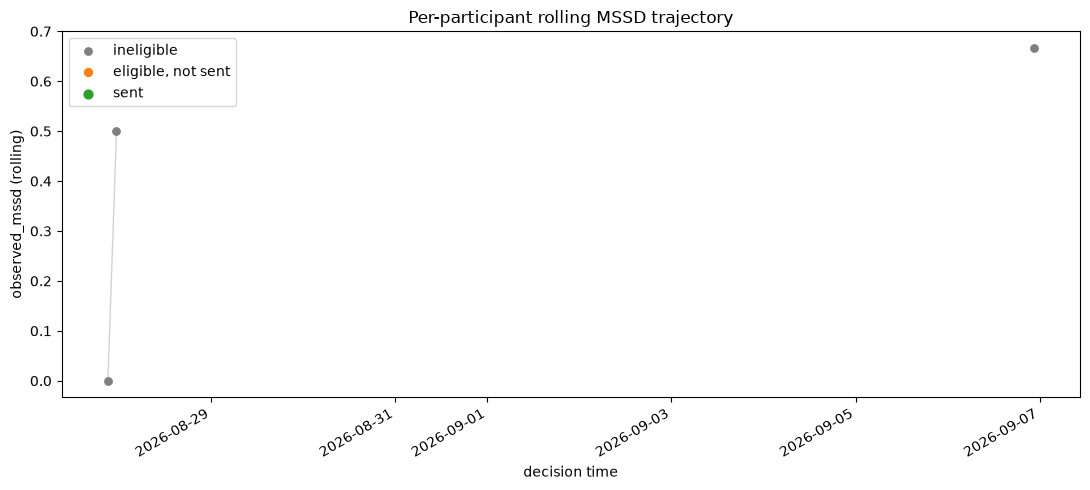

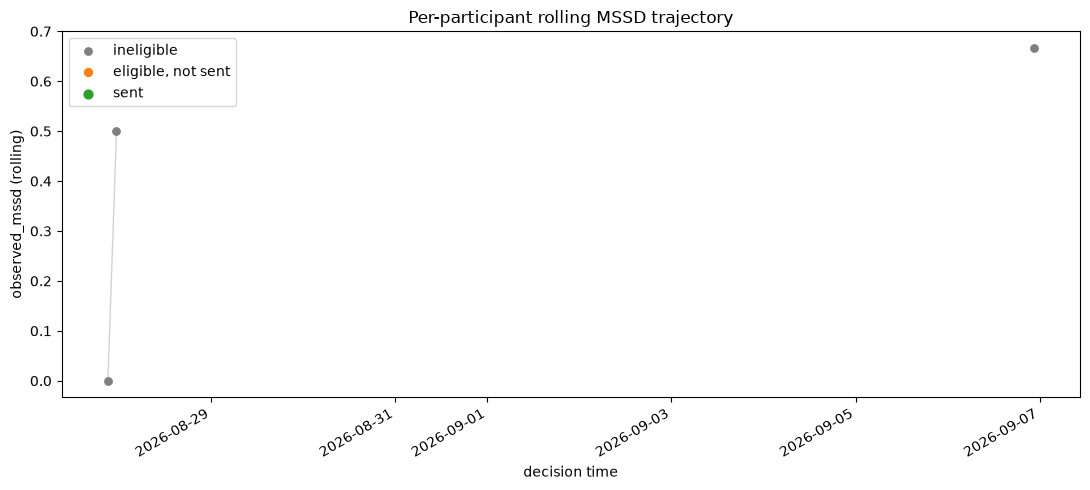

In [59]:
# Rolling observed_mssd trajectory for this participant (read from JITAILog).
SCRIPTS.plot_participant_mssd_trajectory(SCRIPTS.load_jitai_log(user_id=uid))

In [60]:
# Step 14 — Moderation framework (SYNTHETIC DEMO)
# Tier-1/2/3 moderation needs Qualtrics baseline + biomarker frames that are
# not in the operational DB. These moderator scales are generated, not
# collected: the output below is NOT cohort data, it only shows the interface.
rng = np.random.default_rng(0)
n = 40
outcomes = pd.DataFrame(dict(user_id=range(n), outcome_domain=["eating"]*n,
                             outcome_value=rng.normal(size=n),
                             treatment_indicator=[0,1]*(n//2)))
mods1 = pd.DataFrame(dict(user_id=range(n),
    supps_p=rng.normal(size=n), ders_16=rng.normal(size=n), tfeq_r18=rng.normal(size=n),
    dmq_r=rng.normal(size=n), maia_2=rng.normal(size=n)))
print("Tier 1 (confirmatory) moderation:")
display(SCRIPTS.compute_tier1_moderation(outcomes, mods1))

mods3 = pd.DataFrame(dict(user_id=range(n),
    macarthur_ladder=rng.normal(size=n), everyday_discrimination=rng.normal(size=n),
    rmeq_score=rng.normal(size=n)))
print("Tier 3 (exploratory) moderation with Bonferroni:")
display(SCRIPTS.compute_tier3_exploratory(outcomes, mods3))

Tier 1 (confirmatory) moderation:


,moderator,interaction_estimate,se,p_value,ci_lower,ci_upper
0,supps_p,-0.257273,0.232819,0.276476,-0.729452,0.214906
1,ders_16,-0.338868,0.269445,0.216614,-0.885327,0.207591
2,tfeq_r18,0.110822,0.258694,0.670919,-0.413834,0.635479
3,dmq_r,-0.131295,0.263804,0.621722,-0.666315,0.403724
4,maia_2,0.092920,0.222536,0.678754,-0.358403,0.544244


Tier 3 (exploratory) moderation with Bonferroni:


,moderator,interaction_estimate,se,p_value,ci_lower,ci_upper,bonferroni_corrected_p
0,macarthur_ladder,0.541159,0.218362,0.018026,0.098301,0.984017,0.054079
1,everyday_discrimination,0.037064,0.248926,0.882466,-0.467781,0.541909,1.000000
2,rmeq_score,0.026320,0.292988,0.928919,-0.567887,0.620526,1.000000


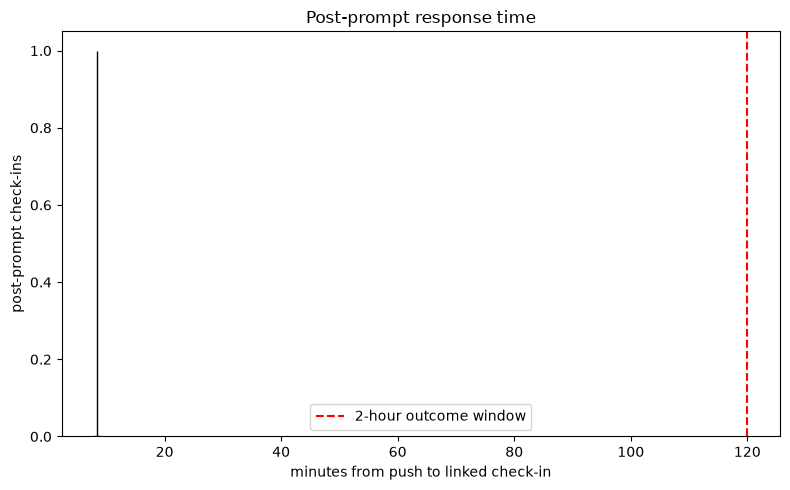

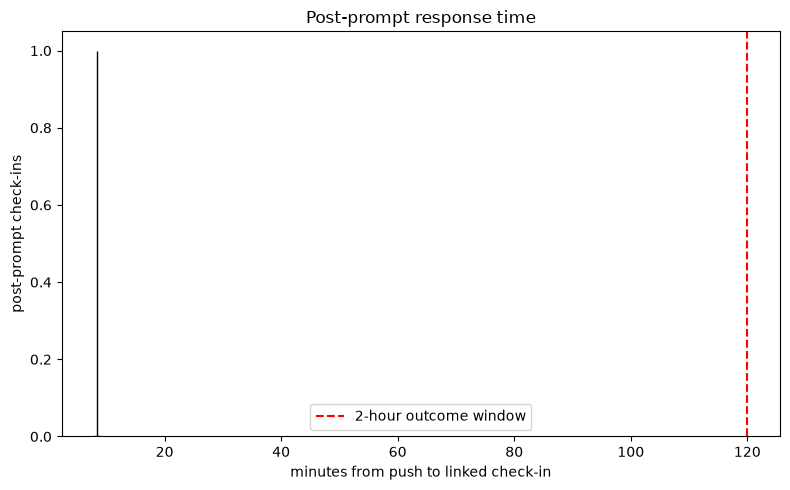

In [61]:
# Step 15 — Feasibility figures (cohort)
# Post-prompt response time: push -> linked post-prompt check-in, against the
# 2-hour outcome window.
#
# This replaced an "EMA response latency" histogram, which could only ever show a
# perfect curve. An app_ema row is created when the participant submits, and
# sent_at and responded_at are both stamped from the same clock read at that
# moment, so every latency is ~0 and every response falls inside the 30-minute
# window. The dashboard omits it for the same reason. Do not add it back.
SCRIPTS.plot_post_prompt_response_time(ema_df, jitai_df)

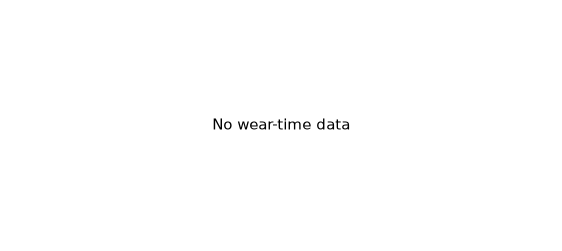

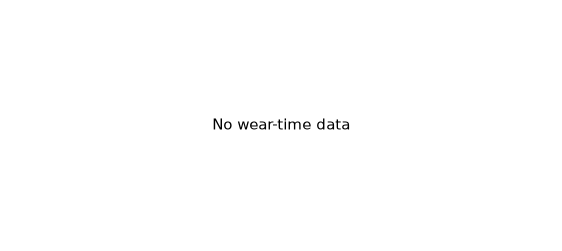

In [62]:
SCRIPTS.plot_wear_time_heatmap(hr_df)

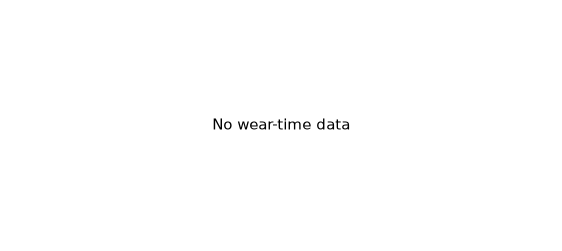

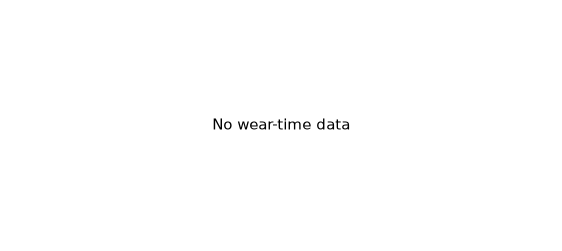

In [63]:
SCRIPTS.plot_wear_hours_distribution(hr_df)

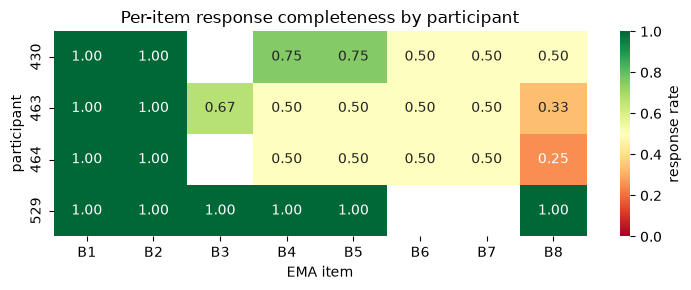

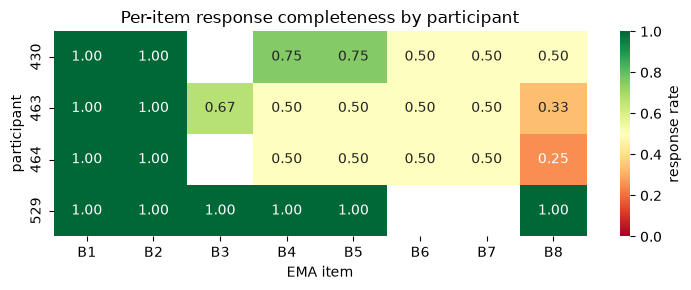

In [64]:
SCRIPTS.plot_bitem_missingness(item_df)

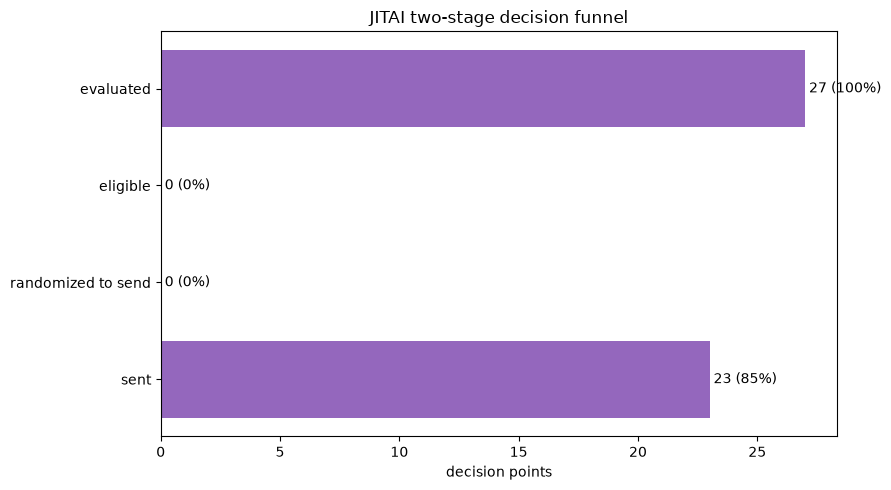

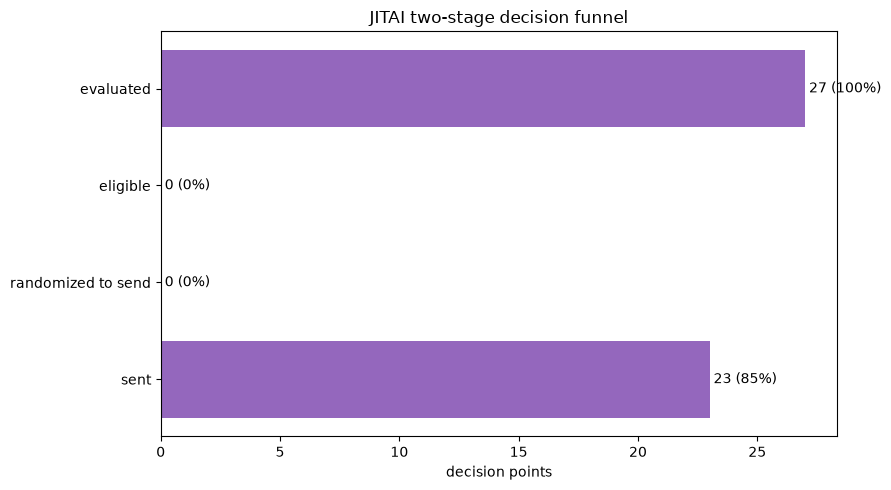

In [65]:
SCRIPTS.plot_decision_funnel(jitai_df)

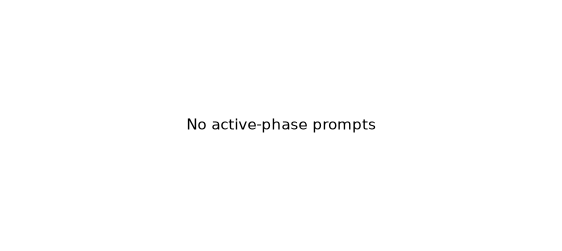

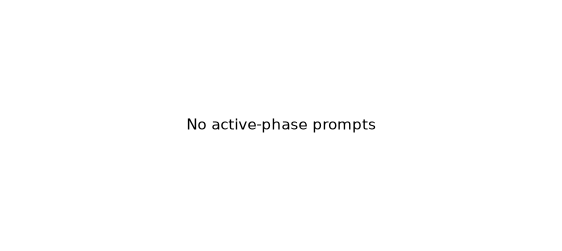

In [66]:
SCRIPTS.plot_intervention_dosage(jitai_df, user_df)

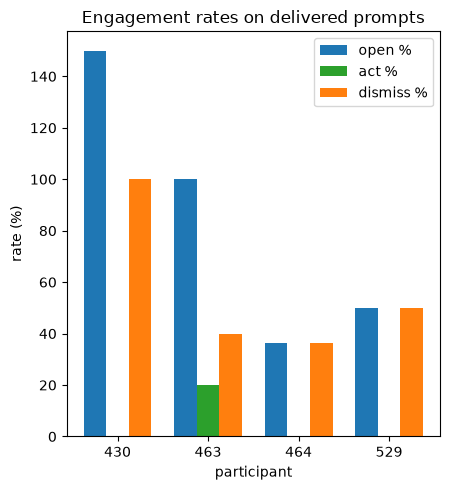

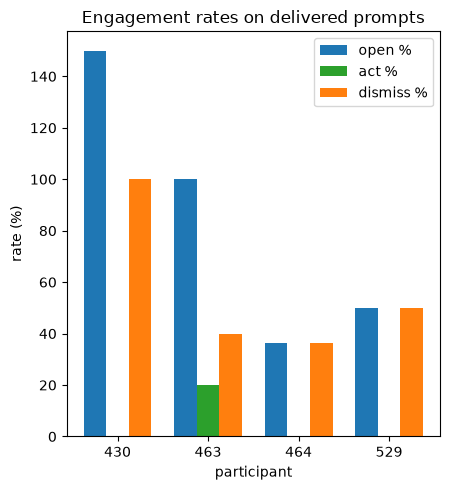

In [67]:
SCRIPTS.plot_engagement_rates(eng_df, jitai_df)

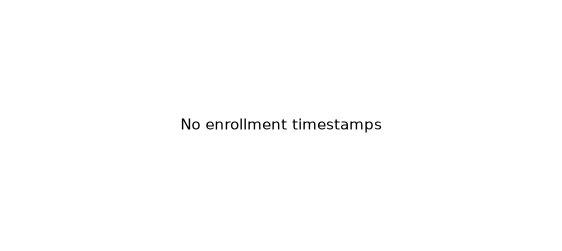

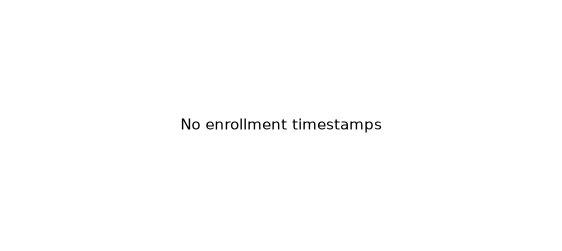

In [68]:
SCRIPTS.plot_retention_curve(user_df)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


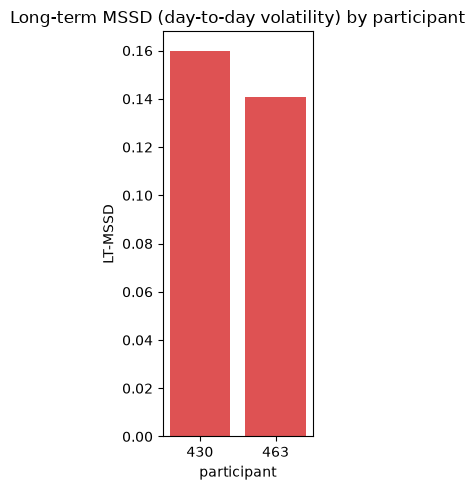

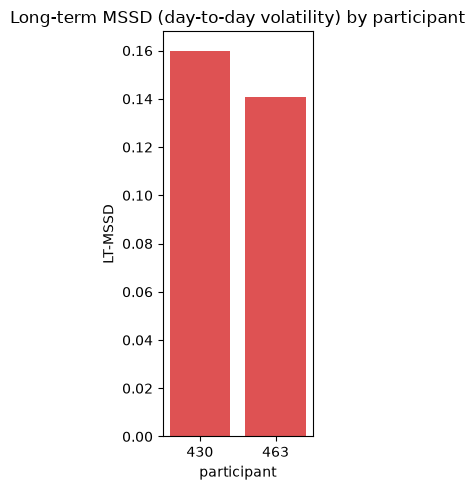

In [69]:
SCRIPTS.plot_lt_mssd_by_participant(signal)

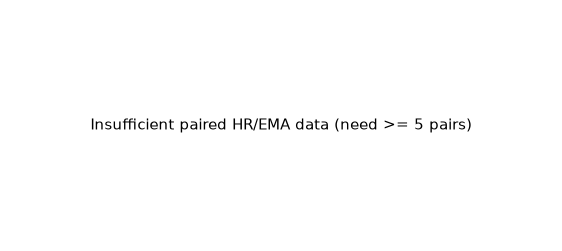

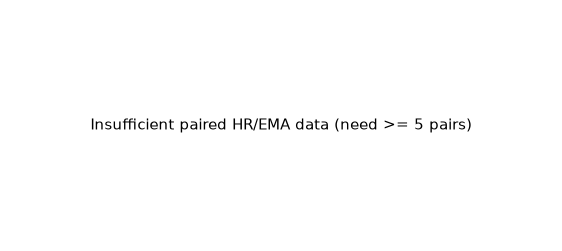

In [70]:
SCRIPTS.plot_hr_ema_concordance(hr_df, signal)

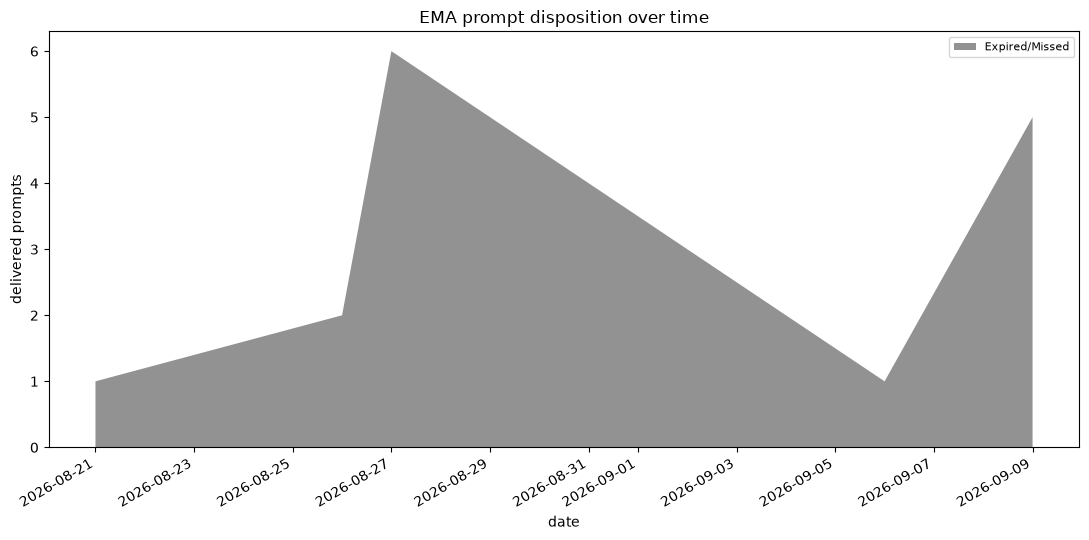

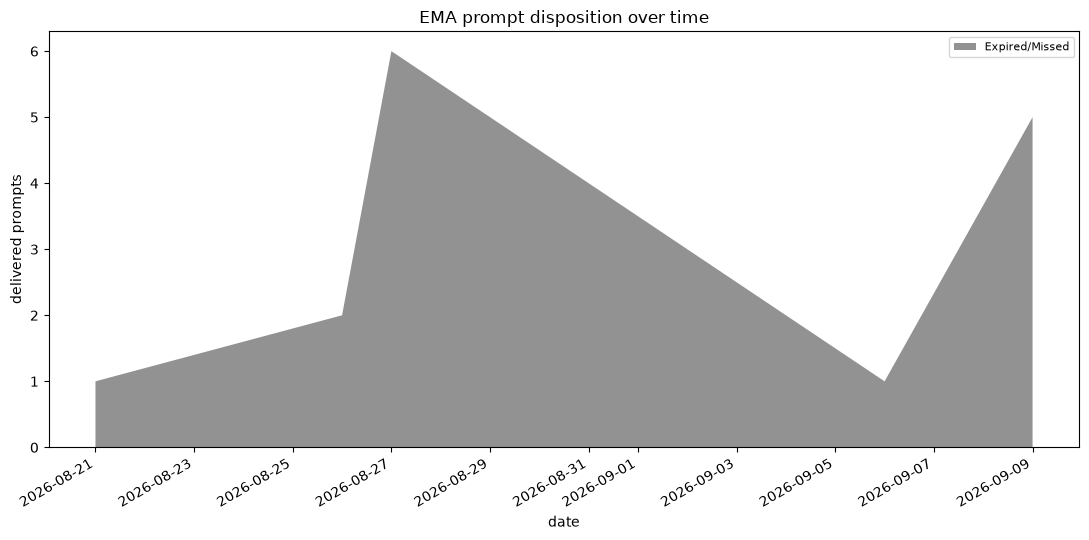

In [71]:
# Step 15b — Additional decomposed / stratified figures
# EMA disposition decomposition, per-participant MSSD facets, OS/app-state
# delivery stratification, and the JITAI decision-rule timeline.
SCRIPTS.plot_ema_disposition_over_time(ema_df)

/Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/scripts.py:3671: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


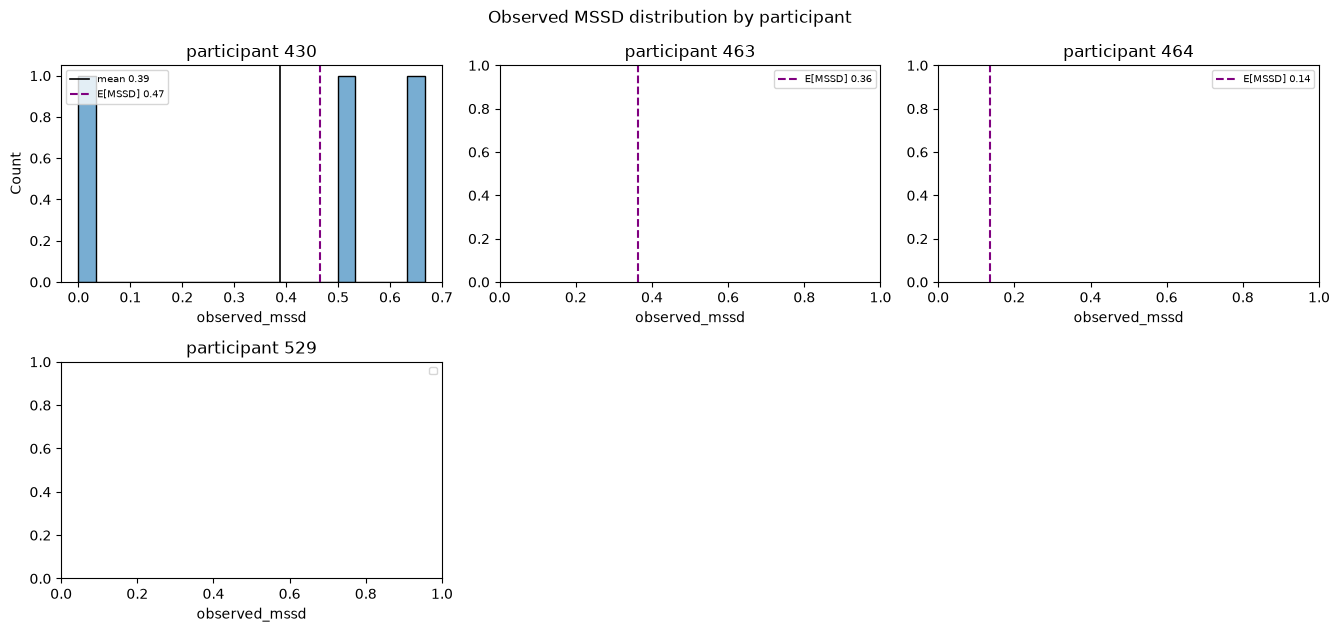

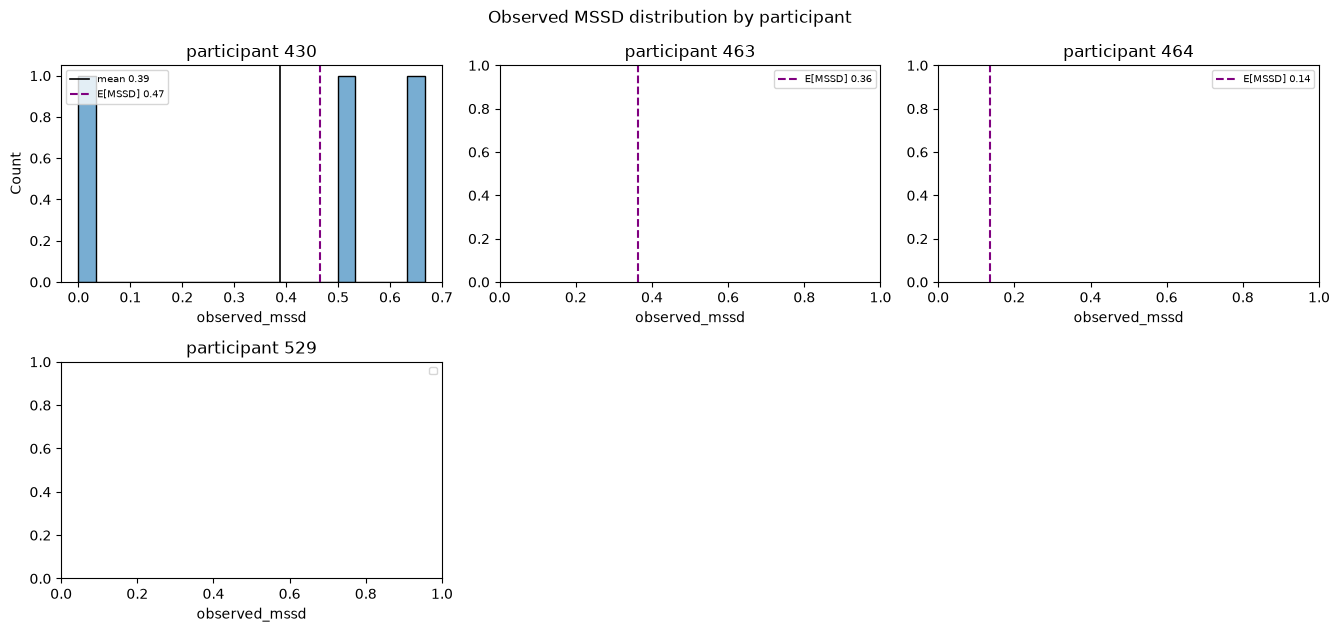

In [72]:
SCRIPTS.plot_mssd_distribution_by_participant(jitai_df, item_df=item_df)

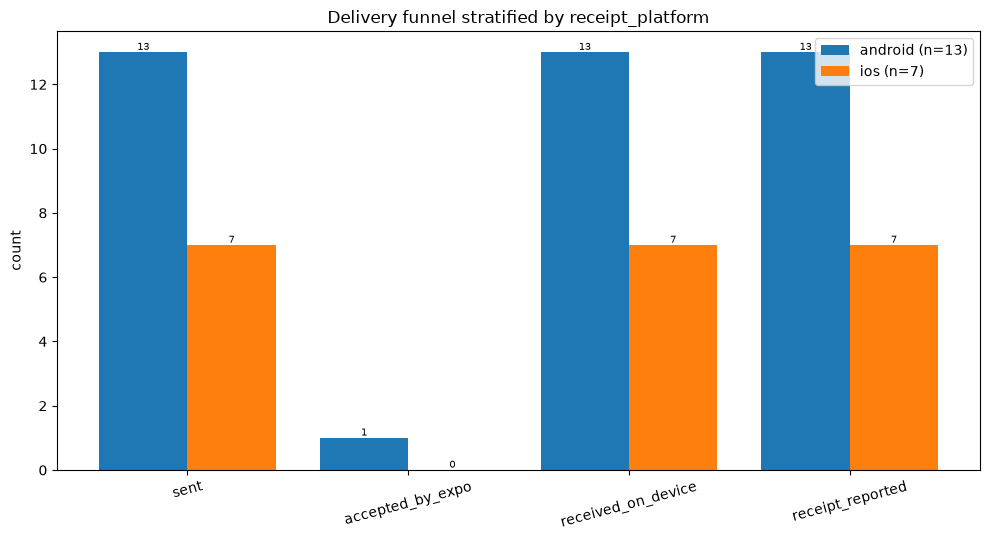

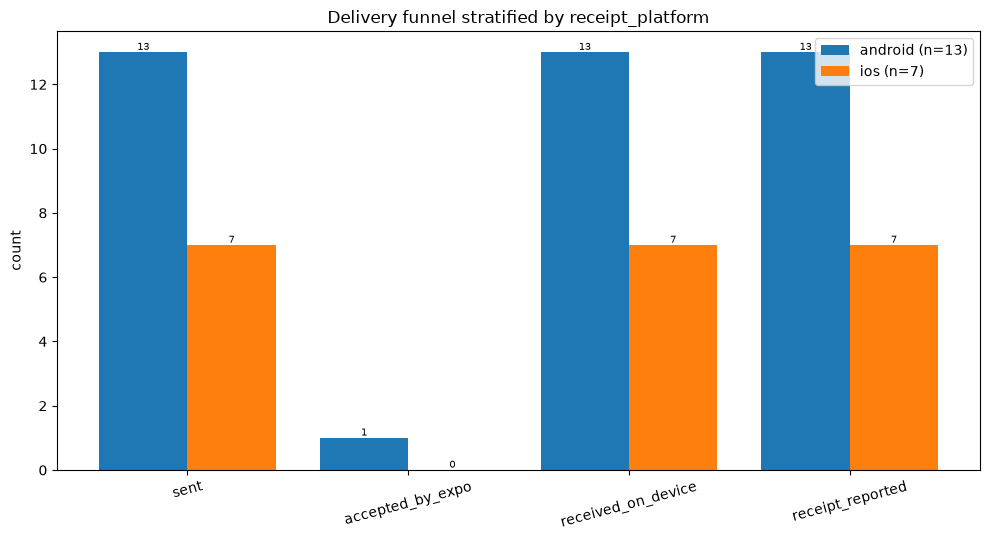

In [73]:
SCRIPTS.plot_delivery_funnel_stratified(jitai_df, by="receipt_platform")

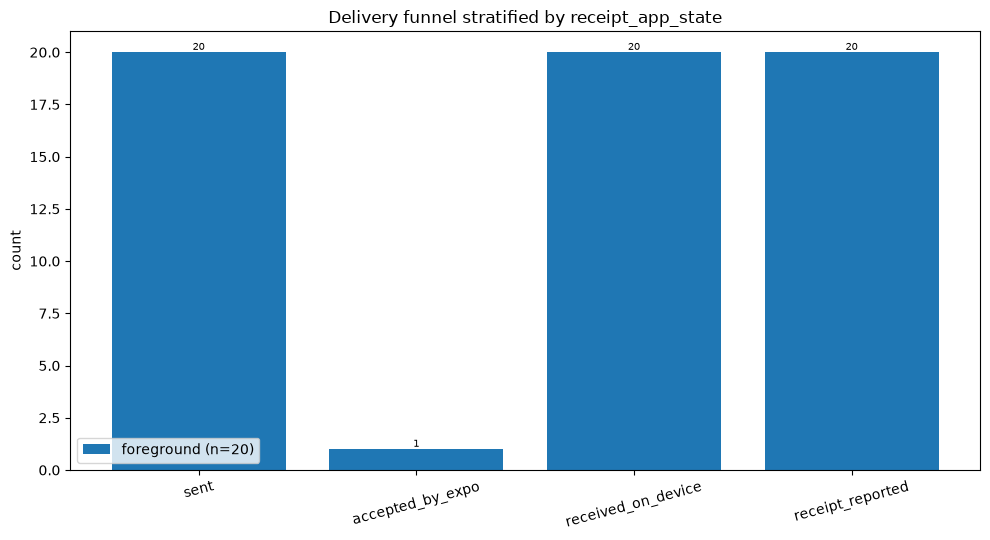

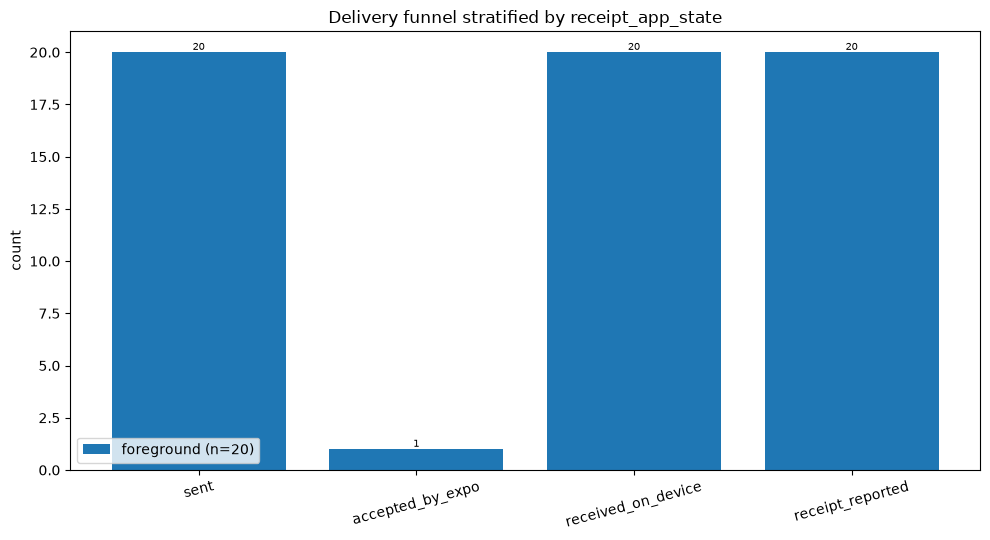

In [74]:
SCRIPTS.plot_delivery_funnel_stratified(jitai_df, by="receipt_app_state")

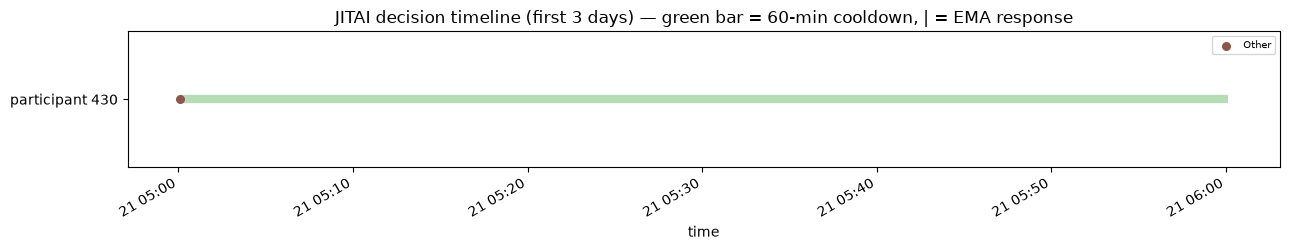

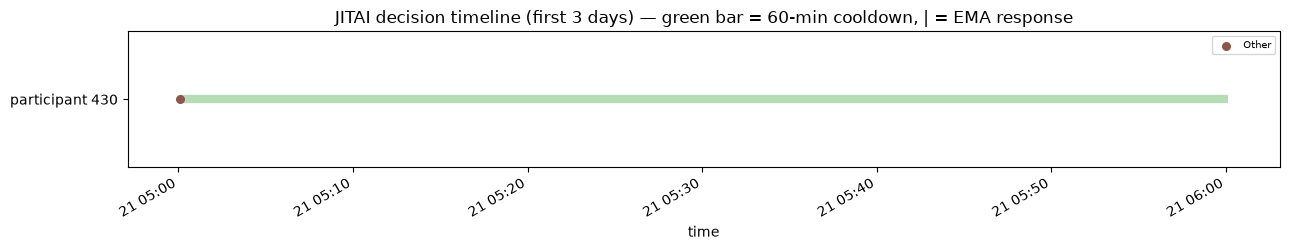

In [75]:
SCRIPTS.plot_jitai_decision_timeline(jitai_df, ema_df, day_window=3)

In [76]:
# Step 16-18 prelude — the dashboard compute layer, read directly.
# No STAGES_OK gate here: this notebook has no synthetic fallback, so a failed
# import is a broken environment and should say so rather than silently skipping
# thirteen cells.
from dashboard.data.cohort import compute_cohort
from dashboard.data.daily import compute_daily
from dashboard.data.participant import compute_participant, compute_risk_score
from dashboard.data.timeline import (
    completeness_matrix, delivery_funnel, mssd_lane, sync_lane, wear_lane,
)
from dashboard.data.windows import local_dates_for, study_day_for, today_local
from dashboard.data.config import STUDY_DAYS
from dashboard.models import Alert
from app.models import EMA, User


def check(label, left, right, tolerance=1e-9):
    """Print a visible pass/fail instead of asserting.

    A bare assert would abort the notebook on the first disagreement, which is
    exactly when you most want to see the remaining comparisons.
    """
    if left is None or right is None:
        print(f"  --   {label}: not computable (left={left!r}, right={right!r})")
        return None
    ok = abs(float(left) - float(right)) <= tolerance
    print(f"  {'PASS' if ok else 'FAIL'} {label}: {left:.6g} vs {right:.6g}")
    return ok


print("Dashboard compute layer loaded.")

Dashboard compute layer loaded.


In [77]:
# Step 16 — Stage 1: cohort board
snapshot = compute_cohort("all")
print(f"participants={snapshot['n_participants']}  active={snapshot['n_active']}\n")

print("Benchmark tiles")
for name, entry in snapshot["benchmarks"].items():
    if not entry["measurable"]:
        state = "no source"
    elif entry["suppressed"]:
        # Below RATE_MIN_PARTICIPANTS/RATE_MIN_UNITS: counts only, never a
        # percentage computed from a handful of people.
        state = "suppressed"
    else:
        state = f"{entry['value']:.1%}  CI [{entry['wilson_low']:.1%}, {entry['wilson_high']:.1%}]"
    target = f"target {entry['target']:.0%}" if entry.get("target") else ""
    print(f"  {name:16} {state:34} {entry['numerator']}/{entry['denominator']:<6} {target}")

print("\nEnrollment funnel")
for stage in snapshot["funnel"]:
    n = stage["n"] if stage["measurable"] else "no source"
    print(f"  {stage['stage']:18} {n}")

participants=0  active=0

Benchmark tiles
  slot_coverage    suppressed                         0/0      target 75%
  prompt_response  suppressed                         0/0      target 70%
  wear             suppressed                         0/0      target 80%
  retention        suppressed                         0/0      target 85%

Enrollment funnel
  consented          no source
  started day 1      0
  active today       0
  completed day 34   0
  withdrew           0


In [78]:
print("MRT integrity (weeks 2-5) — this strip, not the tiles, says whether the trial is analysable\n")
integrity = snapshot["integrity"]
for key, gauge in integrity.items():
    if key == "window":
        continue
    if key == "randomization_audit":
        print(f"  {key:20} draws={gauge['draws']} mismatches={gauge['mismatches']} "
              f"KS p={gauge['ks_p_value']}")
    elif key == "cooldown_violations":
        print(f"  {key:20} {gauge['violations']} under {gauge['cooldown_minutes']} min")
    else:
        value = "—" if gauge["value"] is None else f"{gauge['value']:.1%}"
        # A numerator above its denominator is a contradiction, not a thin
        # sample: a prompt sent on a decision point never marked eligible.
        flag = "  <-- CONTRADICTION" if gauge.get("contradiction") else ""
        print(f"  {key:20} {value:>7}  ({gauge['numerator']}/{gauge['denominator']}){flag}")

ratio = integrity["eligibility_rate"]["decision_points_per_scheduled_ema"]
if ratio is not None:
    print(f"\n  decision points per scheduled check-in: {ratio:.2f}")
    print("  A decision point only exists once an EMA is submitted, so availability is")
    print("  confounded with compliance. The eligibility gauge is not a property of the")
    print("  engine alone and must not be read as one.")

MRT integrity (weeks 2-5) — this strip, not the tiles, says whether the trial is analysable

  eligibility_rate           —  (0/0)
  send_rate                  —  (0/0)
  randomization_audit  draws=0 mismatches=0 KS p=None
  cap_hit_rate               —  (0/0)
  cooldown_violations  0 under 60 min
  outcome_capture            —  (0/0)


In [79]:
print("Cross-check against the pandas path\n")
wear_entry = snapshot["benchmarks"]["wear"]
# Step 6 computes wear percentages independently, in pandas, from the same rows.
offline_wear = SCRIPTS.compute_wear_time(hr_df)
if not offline_wear.empty and wear_entry.get("mean_coverage") is not None:
    check("wear mean coverage (Step 6 vs Stage 1)",
          offline_wear["wear_pct"].mean() / 100.0,
          wear_entry["mean_coverage"], tolerance=0.02)
else:
    print("  --   wear: no scored participant-days on either side")

ret = snapshot["benchmarks"]["retention"]
offline_ret = SCRIPTS.compute_retention(user_df)
check("retention retained (Step 10 vs Stage 1)",
      float(offline_ret["retained_n"]), float(ret["numerator"]))
check("retention denominator (Step 10 vs Stage 1)",
      float(offline_ret["overall_n"]), float(ret["denominator"]))

# Slot coverage is deliberately NOT expected to equal the Step 4 EMA response
# rate. It is a proxy for the 75% check-in benchmark, scored on the day's six
# fixed slots rather than on EMA rows, which is why the tile says "(proxy)".
cov = snapshot["benchmarks"]["slot_coverage"]
print(f"\n  slot coverage (proxy) {cov['numerator']}/{cov['denominator']}"
      f"   participant mean "
      f"{'—' if cov.get('participant_mean') is None else format(cov['participant_mean'], '.1%')}")
print("  Not comparable to the Step 4 EMA response rate by design: different denominator.")

Cross-check against the pandas path

  --   wear: no scored participant-days on either side
  PASS retention retained (Step 10 vs Stage 1): 0 vs 0
  PASS retention denominator (Step 10 vs Stage 1): 0 vs 0

  slot coverage (proxy) 0/0   participant mean —
  Not comparable to the Step 4 EMA response rate by design: different denominator.


In [80]:
# Step 17 — Stage 2: participant grid
# The dashboard counts study days forward from enrolled_at, so a participant
# without one cannot be placed on the grid at all. Say that plainly instead of
# failing on an empty frame further down.
participants = list(User.objects.filter(enrolled_at__isnull=False).order_by("pk"))
undated = SCRIPTS.undated_enrollments(user_df)
print(f"{len(participants)} enrolled participant(s) with an enrollment date")
if undated:
    print(f"{len(undated)} enrolled participant(s) have NO enrolled_at: {undated}")
    print("Run `python manage.py backfill_enrollment` in backend/ to stamp them")
    print("from their earliest recorded activity. Until then Steps 17-18 have no")
    print("study clock to measure against and the grid below stays empty.")
print()

GRID_COLUMNS = ["is_active_day", "slots_expected", "slots_covered",
                "slots_reminded_uncovered", "slots_silent", "delivered_n",
                "completeness_mean", "wear_valid_pct"]

grid_rows = []
for user in participants:
    for local_date, study_day in local_dates_for(user, n_trailing=STUDY_DAYS):
        metrics = compute_daily(user, local_date, study_day=study_day)
        grid_rows.append({
            "user_id": user.pk, "study_day": study_day, "local_date": local_date,
            **{k: metrics[k] for k in GRID_COLUMNS},
        })
# Name the columns explicitly so an empty cohort yields an empty grid with the
# right shape rather than a column-less frame that KeyErrors on first access.
grid = pd.DataFrame(grid_rows, columns=["user_id", "study_day", "local_date"] + GRID_COLUMNS)
print(f"participant-days: {len(grid)}  active: {int(grid['is_active_day'].sum())}")
display(grid.head(10))

0 enrolled participant(s) with an enrollment date
1 enrolled participant(s) have NO enrolled_at: [430]
Run `python manage.py backfill_enrollment` in backend/ to stamp them
from their earliest recorded activity. Until then Steps 17-18 have no
study clock to measure against and the grid below stays empty.

participant-days: 0  active: 0


,user_id,study_day,local_date,is_active_day,slots_expected,slots_covered,slots_reminded_uncovered,slots_silent,delivered_n,completeness_mean,wear_valid_pct


In [81]:
# Slot coverage as the heatmap draws it. NaN is a day outside the participant's
# window and must stay visually distinct from 0, which is a lived day with no
# check-in. Collapsing the two is the one thing this layer exists not to do.
active = grid[grid["is_active_day"].fillna(False).astype(bool)].copy()
if active.empty:
    print("No active participant-days to pivot. See the enrollment-date note above.")
else:
    active["coverage"] = active["slots_covered"] / active["slots_expected"]
    pivot = active.pivot_table(index="user_id", columns="study_day", values="coverage")
    display(pivot.style.format("{:.0%}", na_rep="").set_caption(
        "Slot coverage by participant x study day (blank = outside the window)"))

    split = active[["slots_covered", "slots_reminded_uncovered", "slots_silent"]].sum()
    print("\nWhere the empty slots went, cohort-wide:")
    for label, value in split.items():
        print(f"  {label:26} {int(value)}")
    print("\n  'silent' means no check-in AND no reminder: the scheduler never asked.")
    print("  That is a system failure, not non-response, and nobody should be called about it.")

No active participant-days to pivot. See the enrollment-date note above.


In [82]:
print("Risk score and its components — the ordering has to be arguable, not trusted\n")
for user in participants:
    payload = compute_participant(user)
    score, components = compute_risk_score(user, phase=payload["phase"])
    if score is None:
        # Null, not zero: the study is not currently asking anything of this
        # participant, so ranking them at all would be meaningless.
        print(f"  user {user.pk}: no score ({payload['phase']})")
        continue
    parts = "  ".join(f"{k}={v}" for k, v in sorted(components.items(), key=lambda i: -i[1]))
    print(f"  user {user.pk}: risk {score:2}  [{payload['phase']}]  {parts}")

print("\nCross-check against Step 13 (per-participant report)")
for user in participants[:1]:
    payload = compute_participant(user)
    check("slot coverage numerator (Stage 2 rollup vs grid sum)",
          float(payload["slot_coverage_num"]),
          float(grid[(grid.user_id == user.pk) & grid.is_active_day]["slots_covered"].sum()))

Risk score and its components — the ordering has to be arguable, not trusted


Cross-check against Step 13 (per-participant report)


In [83]:
# Step 18 — Stage 3: participant timeline
subject = participants[0] if participants else None
if subject is None:
    print("No participant has an enrolled_at, so there is no study clock to lay a")
    print("timeline against. Run `python manage.py backfill_enrollment` in backend/")
    print("and re-run from Step 17.")
else:
    days = [d for d, _ in local_dates_for(subject, n_trailing=STUDY_DAYS)]
    with_ema = [d for d in days
                if EMA.objects.filter(user=subject,
                                      sent_at__date__gte=d, sent_at__date__lte=d).exists()]
    focus = with_ema[-1] if with_ema else (days[-1] if days else today_local())
    print(f"user {subject.pk}, {focus} (study day {study_day_for(subject, focus)})\n")

    wear = wear_lane(subject, focus)
    print(f"Wear: {wear['covered_minutes']} covered minutes, "
          f"{len(wear['gaps'])} gaps, {sum(g['over_threshold'] for g in wear['gaps'])} over 2 h")
    if not wear["has_data"]:
        print("  No heart-rate samples: the pipeline delivered nothing, which is NOT 0% wear.")

    sync = sync_lane(subject, focus)
    print(f"Sync: observed={sync['observed']}  advances={len(sync['advances'])}")
    if not sync["observed"]:
        print("  No sync history. last_synced_at has no writer yet, so staleness is")
        print("  unmeasurable rather than bad, and no per-participant alert fires.")

No participant has an enrolled_at, so there is no study clock to lay a
timeline against. Run `python manage.py backfill_enrollment` in backend/
and re-run from Step 17.


In [84]:
if subject is None:
    print("Skipped: no participant has an enrolled_at (see Step 18 above).")
else:
    points = mssd_lane(subject, focus)
    print(f"Decision points: {len(points)}")
    for point in points:
        threshold = "—" if point["threshold"] is None else f"{point['threshold']:.3f}"
        flag = "  <-- ABOVE THRESHOLD BUT NOT ELIGIBLE" if point["unexplained"] else ""
        print(f"  {point['at']:%H:%M}  mssd={point['observed_mssd']}  thr={threshold}"
              f"  [{point['threshold_source']}]  {point['trigger_reason']}{flag}")
    print("\n  The bug marker fires only on threshold_source='engine'. A replayed threshold")
    print("  can disagree for reasons that are not the engine's fault, so it is never")
    print("  grounds for accusing the engine of missing an eligible decision point.")

    rows = completeness_matrix(list(
        EMA.objects.filter(user=subject, sent_at__date=focus).prefetch_related("item_responses")))
    if rows:
        display(pd.DataFrame([{
            "ema_type": r["ema_type"], "served": len(r["served"]),
            "askable": len(r["askable"]), "answered": len(r["answered"]),
            "completeness": r["completeness"], "missing_B1_B2": r["missing_signal"],
        } for r in rows]))
        if any(r["missing_signal"] for r in rows):
            print("A check-in is missing B1 or B2. Those feed calculate_mssd, so it produced")
            print("no volatility signal and therefore no decision point: a hole in the MRT.")

Skipped: no participant has an enrolled_at (see Step 18 above).


In [85]:
if subject is None:
    print("Skipped: no participant has an enrolled_at (see Step 18 above).")
else:
    funnel = delivery_funnel(subject)
    print("Delivery funnel (whole study, this participant)\n")
    for stage in funnel["stages"]:
        drop = "" if stage["dropped"] is None else f"  dropped {stage['dropped']}"
        print(f"  {stage['stage']:18} {stage['n']:4}{drop}")
    counts = [stage["n"] for stage in funnel["stages"]]
    print(f"\n  monotonically non-increasing: {counts == sorted(counts, reverse=True)}")
    print(f"  anomalies: {funnel['anomalies']}")
    print("  An anomaly is a prompt that SKIPPED a stage rather than failing at one -")
    print("  a receipt with no push timestamp, say. Counted here so it cannot inflate a")
    print("  later stage and turn the waterfall into nonsense.")

    print("\nCross-check against Step 8 (pandas delivery funnel)")
    offline = SCRIPTS.compute_delivery_funnel(jitai_df[jitai_df["user_id"] == subject.pk])
    display(offline)
    print("  Both nest their stages, so the eligible/sent counts should agree; the")
    print("  later stages can differ where Step 8 counts a stage independently.")

Skipped: no participant has an enrolled_at (see Step 18 above).
